
#Evaluating a Decision Tree (Accuracy, Precision, Recall, F1, Confusion Matrix)




In [44]:
import numpy as np
import pandas as pd
np.random.seed(42)
n_sample=300

age=np.random.randint(30,80, size=n_sample)
chol=np.random.randint(150, 3090, size= n_sample)
thalach= np.random.randint(90, 200, size=n_sample)

risk_score= 0.03* (age-40) + 0.02 * (chol- 200) - 0.02 * ( thalach -140)
prob= 1/ (np.exp(-0.05 * risk_score))

target=(prob > np.median(prob).astype(int))
df_heart=pd.DataFrame({
    'age':age,
    'chol':chol,
    'thalach':thalach,
    'target':target
})
df_heart.head()

,age,chol,thalach,target
0,68,1593,174,True
1,58,1595,189,True
2,44,253,142,False
3,72,403,112,False
4,37,2707,105,True


We now split the dataset into training and test sets and train a decision tree classifier.

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
#train tesst split model tarining

x_h=df_heart[['age','chol','thalach']]
y_h=df_heart['target']

x_train_h, x_test_h, y_train_h, y_test_h= train_test_split(
    x_h, y_h, test_size= 0.2, random_state=42
)
tree_heart=DecisionTreeClassifier(max_depth= 4, random_state=42)
tree_heart.fit(x_train_h, y_train_h)

DecisionTreeClassifier(max_depth=4, random_state=42)

 Confusion matrix

In [46]:
from sklearn.metrics import confusion_matrix
y_pred_h= tree_heart.predict(x_test_h)
cm=confusion_matrix(y_test_h, y_pred_h)
print(cm)

[[21  0]
 [ 2 37]]


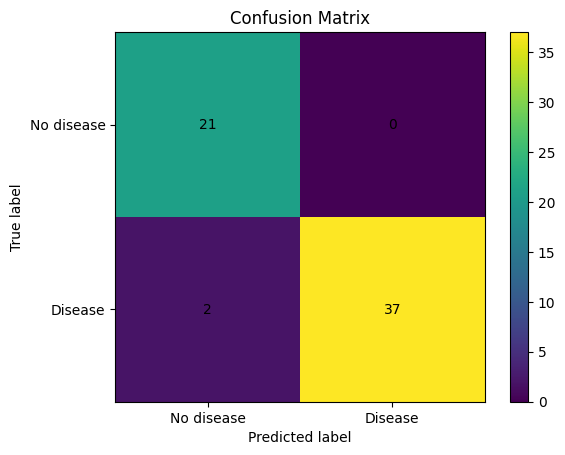

In [47]:
import matplotlib.pyplot as plt
#plot of confusion matrix
fig,ax=plt.subplots()
im=ax.imshow(cm, interpolation='nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# Show all ticks and label them
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["No disease", 'Disease'])
ax.set_yticklabels(["No disease", 'Disease'])
# Loop over data dimensions and create text annotations.
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(j,i,cm[i,j], ha='center', va='center')

plt.colorbar(im)
plt.show()

Accuracy, precision, recall, F1

In [48]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)

acc=accuracy_score(y_test_h, y_pred_h)
prec= precision_score(y_test_h, y_pred_h)
rec= recall_score(y_test_h, y_pred_h)
f1= f1_score( y_test_h, y_pred_h)
print('Accuracy :', round(acc, 3))
print('Precision:', round(prec, 3))
print('Recall   :', round(rec, 3))
print('F1 score :', round(f1, 3))

Accuracy : 0.967
Precision: 1.0
Recall   : 0.949
F1 score : 0.974


 Predicted probabilities

In [49]:
#Predicted probabilities
y_proba_h = tree_heart.predict_proba(x_test_h)[:, 1]
y_proba_h[:10]

array([1., 1., 0., 1., 1., 1., 1., 0., 1., 1.])

 ROC curve and AUC

In [50]:
fpr, tpr, thresholds = roc_curve(y_test_h, y_proba_h)
roc_auc= auc(fpr, tpr)
print('AUC: ',round(roc_auc, 3))

AUC:  0.974


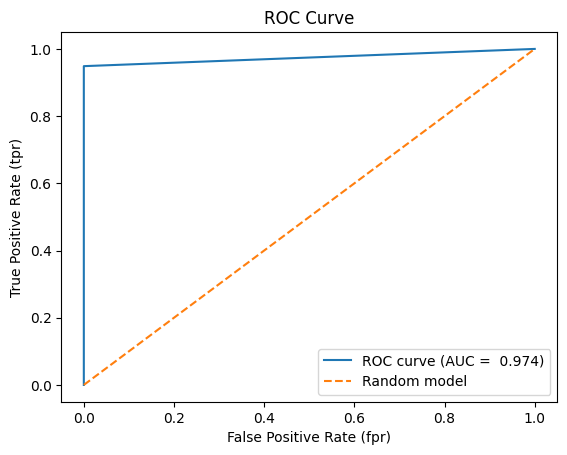

In [51]:
from matplotlib.lines import lineStyles
#plot
plt.plot(fpr,tpr, label=f'ROC curve (AUC = {roc_auc: .3f})')
plt.plot([0,1], [0,1], linestyle='--', label='Random model')
plt.xlabel('False Positive Rate (fpr)')
plt.ylabel('True Positive Rate (tpr)')
plt.title("ROC Curve")
plt.legend()
plt.show()
